In [1]:
# !pip uninstall -y oceanttds

In [2]:
# !pip install "git+https://github.com/anthony-meza/oceanttds.git@inverse-gaussian"

In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from oceanttds import * 
from tqdm.notebook import tqdm

import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")


In [2]:
import cmocean.cm as cmo

In [7]:
ds.thkcello

<xarray.DataArray 'thkcello' (exp: 2, time: 60, sigma2_l: 76, yh: 224, xh: 240)> Size: 4GB
dask.array<open_dataset-thkcello, shape=(2, 60, 76, 224, 240), dtype=float64, chunksize=(2, 1, 76, 224, 240), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * exp              (exp) object 16B 'forced' 'control'
  * time             (time) object 480B 2010-01-16 12:00:00 ... 2014-12-16 12...
  * sigma2_l         (sigma2_l) float64 608B -503.0 4.246 13.57 ... 38.49 539.0
  * yh               (yh) int64 2kB 0 1 2 3 4 5 6 ... 218 219 220 221 222 223
  * xh               (xh) int64 2kB 0 1 2 3 4 5 6 ... 234 235 236 237 238 239
    areacello        (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    ...               ...
    geolon           (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    lat              (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    lon              (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    rho2_l           (sigma2_l) float64 608B dask.array<chunksize=(76,), meta=np.ndarray>
    time_since_init  (time) object 480B dask.array<chunksize=(1,), meta=np.ndarray>
    wet              (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
Attributes:
    long_name:      Cell Thickness
    units:          m
    cell_methods:   area:mean sigma2_l:sum yh:mean xh:mean time:mean
    cell_measures:  volume: volcello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  cell_thickness

In [6]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budgets_sigma2_1p5/CM4Xp125_budgets_sigma2_2010-2014.zarr"
ds = xr.open_mfdataset(ds_path)
ds.thkcello_bounds

<xarray.DataArray 'thkcello_bounds' (exp: 2, time_bounds: 61, sigma2_l: 76,
                                     yh: 224, xh: 240)> Size: 4GB
dask.array<open_dataset-thkcello_bounds, shape=(2, 61, 76, 224, 240), dtype=float64, chunksize=(2, 1, 76, 224, 240), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * exp                     (exp) object 16B 'forced' 'control'
  * time_bounds             (time_bounds) object 488B 2010-01-01 00:00:00 ......
  * sigma2_l                (sigma2_l) float64 608B -503.0 4.246 ... 38.49 539.0
  * yh                      (yh) int64 2kB 0 1 2 3 4 5 ... 219 220 221 222 223
  * xh                      (xh) int64 2kB 0 1 2 3 4 5 ... 235 236 237 238 239
    areacello               (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    ...                      ...
    geolon                  (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    lat                     (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    lon                     (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    rho2_l                  (sigma2_l) float64 608B dask.array<chunksize=(76,), meta=np.ndarray>
    time_bounds_since_init  (time_bounds) object 488B dask.array<chunksize=(1,), meta=np.ndarray>
    wet                     (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
Attributes:
    long_name:      Cell Thickness
    units:          m
    cell_methods:   area:mean sigma2_l:sum yh:mean xh:mean time:mean
    cell_measures:  volume: volcello
    standard_name:  cell_thickness

In [36]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds = xr.open_mfdataset(ds_path)
ds = ds.sel(year = slice(None, 2099))
ds = ds.where(ds.depth < -2500)

In [37]:
# --- 1. SETUP ---
# Grid MUST NOT contain 0 to avoid singularity in Inverse Gaussian PDF.
# We start at 0.1 years.
tau_grid = np.concatenate([
    [0.1],                     
    np.arange(3, 76, 3),       
    np.arange(80, 1001, 5),    
    [1200],                     
    np.arange(1500, 4001, 500), 
    [7000, 9000, 11000, 15000, 20000]  
]).astype(float)

In [38]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_boundary_sample_for_ttd.zarr"
ds_b = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__":"boundary_truth"}).fillna(0.0)
ds_b["boundary"] = ds_b["boundary_truth"].copy()

ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_interior_sample_for_ttd.zarr"
ds_i = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__": "interior_truth"}).fillna(0.0)
ds_i = ds_i.sel(time = slice(1940, 2030))
ds_i["interior"] = ds_i["interior_truth"].copy()


# noise_floors = xr.Dataset(
#     {"sigma_obs": (["tracer",], np.array([0.01, 0.01, 0.1]))}, 
#     coords={"tracer": ["cfc11", "cfc12", "sf6"]}
# )["sigma_obs"]

# ds_i["sigma_obs"] = xr.ufuncs.maximum( ds_i["interior_truth"] * 0.05, noise_floors)

ds_i["sigma_obs"] = (ds_i["interior_truth"] * 0.01).clip(min = 0.001)


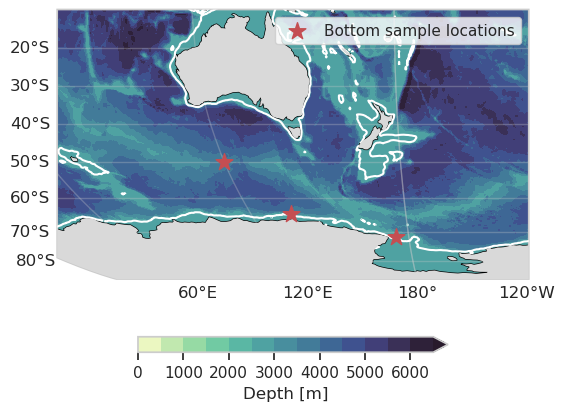

In [39]:
fig, ax = plt.subplots(
    figsize=(8, 5),
    subplot_kw=dict(projection=ccrs.Robinson(central_longitude=-165)),
)

depth = ds.deptho.where(ds.deptho > 10).compute()
levels = np.arange(0, 7000, 500)

pc = ax.contourf(ds["geolon"], ds["geolat"], depth,
                 transform=ccrs.PlateCarree(), levels = levels,extend = "max", 
                cmap = cmo.deep)
ax.contour(ds["geolon"], ds["geolat"], depth,
                 transform=ccrs.PlateCarree(), levels = [1000.0], colors = "white", zorder = 8)

ax.scatter(ds_b.sel(source = "ross").lon, ds_b.sel(source = "ross").lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*")
ax.scatter(ds_b.sel(source = "adelie").lon, ds_b.sel(source = "adelie").lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*")
ax.scatter(ds_i.lon, ds_i.lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*", label = "Bottom sample locations")

ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=8)
ax.coastlines()
# Australian Basin (approx): lon 80E–170E, lat 60S–10S
ax.set_extent([80, 220, -89, -10], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False
fig.colorbar(pc, ax = ax, orientation = "horizontal", shrink = 0.5, label = "Depth [m]")
legend = ax.legend(loc='upper right')

# Set the z-order of the legend (e.g., to a high value like 10)
legend.set_zorder(15) #
fig.savefig('plots/ttd_example_locations.png', dpi = 150, bbox_inches = "tight")

In [40]:
import random
random.seed(42) 

gamma_bounds = (10, 5_000)
delta_gamma_ratio_bounds = (0.65, 2.5)
optimizer_options = {"maxiter": 1000, "ftol": 1e-10, "early_stop": True, "early_stop_cost": 0.5}
warm_start_options = {"maxiter":600}
warm_start = True 
debug = True

p0 = xr.Dataset(data_vars={
  "mass_fraction": (["source"], [0.5, 0.5]),
  "gamma": (["source"], [500, 500]),
  "delta_gamma_ratio": (["source"], [1.5, 1.5]),}, 
  coords={"source": ds_b.source})


results_control = solve_ttd_mixture(ds_b.sel(expt = "control"), ds_i.sel(expt = "control"), tau_grid=tau_grid, debug=debug, 
                            gamma_bounds = gamma_bounds, 
                           delta_gamma_ratio_bounds = delta_gamma_ratio_bounds, 
                                   optimizer_options = optimizer_options, 
                                   p0 = p0, 
                                   warm_start = warm_start, warm_start_options = warm_start_options)

p0 = xr.Dataset(data_vars={
  "mass_fraction": (["source"], [0.5, 0.5]),
  "gamma": (["source"], [500, 500]),
  "delta_gamma_ratio": (["source"], [1.5, 1.5]),}, 
  coords={"source": ds_b.source})


results_forced = solve_ttd_mixture(ds_b.sel(expt = "forced"), ds_i.sel(expt = "forced"), tau_grid=tau_grid, debug=debug, 
                            gamma_bounds = gamma_bounds, 
                           delta_gamma_ratio_bounds = delta_gamma_ratio_bounds, 
                                   optimizer_options = optimizer_options, 
                                   p0 = p0, 
                                   warm_start = warm_start, warm_start_options = warm_start_options)

results = xr.concat([results_control.expand_dims(expt=["control"]), results_forced.expand_dims(expt=["forced"])], dim = "expt")

print("Forced cost: ", results_forced.cost)
print("Control cost: ", results_control.cost)

Forced cost:  13.227461814880371
Control cost:  17.97426986694336


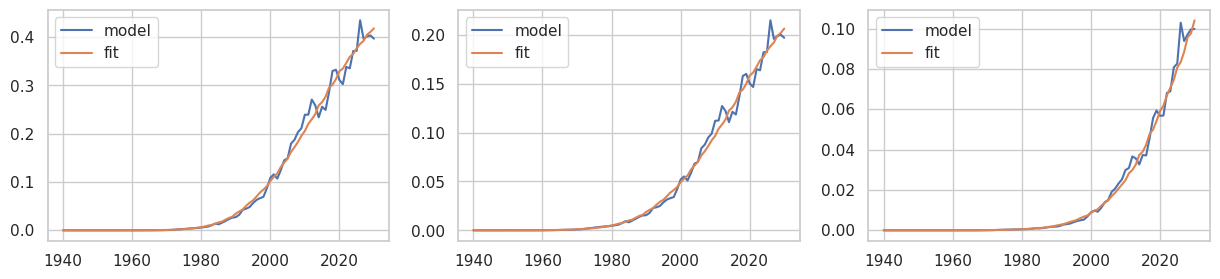

In [42]:
ntracers =len(ds_i.tracer)
expt = "control"
fig, ax = plt.subplots(1, ntracers, figsize = (15, 3))
for (itracer, tracer) in enumerate(ds_i.tracer):
    ax[itracer].plot(ds_i.time, ds_i.sel(expt = expt).interior_truth.sel(tracer = tracer), label = "model")
    ax[itracer].plot(ds_i.time, results.sel(expt = expt).interior_fit.sel(tracer = tracer), label = "fit")
    ax[itracer].legend()

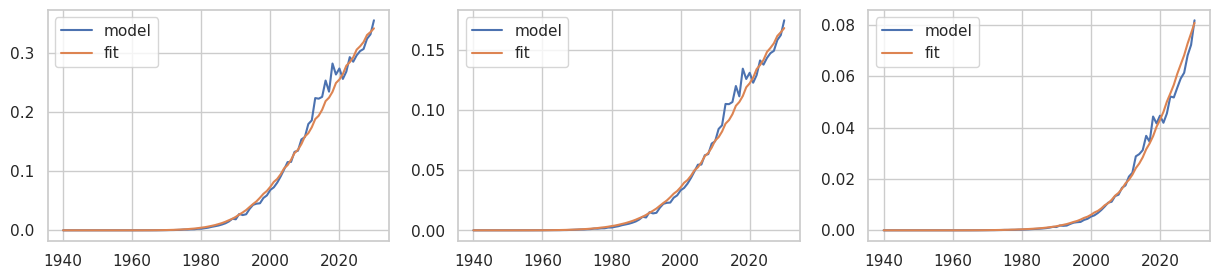

In [43]:
ntracers =len(ds_i.tracer)
expt = "forced"
fig, ax = plt.subplots(1, ntracers, figsize = (15, 3))
for (itracer, tracer) in enumerate(ds_i.tracer):
    ax[itracer].plot(ds_i.time, ds_i.sel(expt = expt).interior_truth.sel(tracer = tracer), label = "model")
    ax[itracer].plot(ds_i.time, results.sel(expt = expt).interior_fit.sel(tracer = tracer), label = "fit")
    ax[itracer].legend()
    

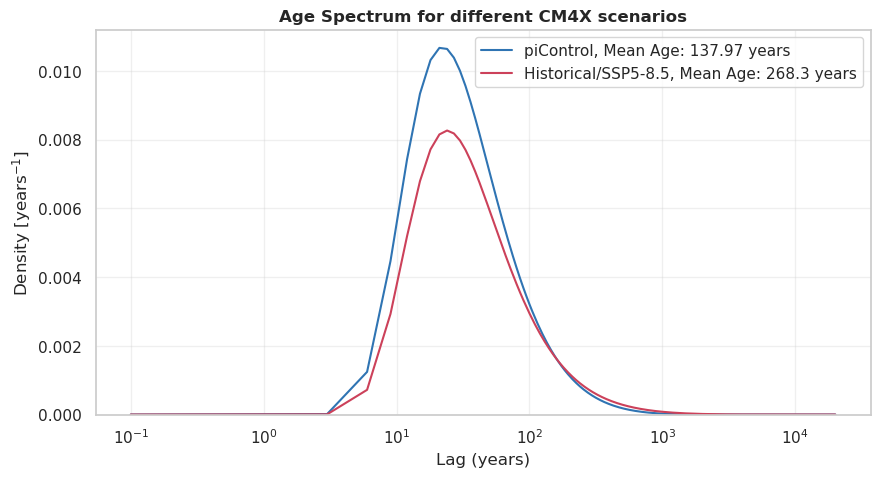

In [44]:
integrator = TTDIntegrator(tau_grid)
tau_dtau = integrator.weights * results.tau
mean_age = (results.age_spectrum* tau_dtau).sum(dim = "tau")

expt_labels = {"control":"piControl", "forced":"Historical/SSP5-8.5"}
expt_colors = {"control": "#2f74b3", "forced": "#cc415a"}
fig, ax = plt.subplots(figsize = (10, 5))
for expt in results.expt.values:
    mean_age_expt = np.round(mean_age.sel(expt = expt).values, decimals = 2)
    ax.plot(results.tau, results.age_spectrum.sel(expt = expt), 
            color = expt_colors[expt],
            label = f"{expt_labels[expt]}, Mean Age: {mean_age_expt} years")
    # ax.axvline(mean_age_expt, c = expt_colors[expt])

ax.set_ylim(0.0, None)
ax.set_xscale('log')
ax.set_xlabel('Lag (years)')
ax.set_ylabel('Density [years' + r"$^{-1}$]")
ax.grid(zorder = 0, alpha = 0.3)
ax.legend()
ax.set_title("Age Spectrum for different CM4X scenarios", fontweight = "bold")
fig.savefig('plots/ross_adelie_bps.png', dpi = 150, bbox_inches = "tight")

In [45]:
def ttd_quantile(G, dtau, q, lag_dim="tau"):
    q = xr.DataArray(np.atleast_1d(q), dims="quantile")
    w = G * dtau
    F = w.cumsum(lag_dim) / w.sum(lag_dim)
    tau = G[lag_dim]
    return xr.apply_ufunc(
        np.interp, q, F, tau,
        input_core_dims=[["quantile"], [lag_dim], [lag_dim]],
        output_core_dims=[["quantile"]],
        vectorize=True, dask="parallelized", output_dtypes=[float],
    ).isel(quantile=0, drop=True) if np.ndim(q) == 0 else xr.apply_ufunc(
        np.interp, q, F, tau,
        input_core_dims=[["quantile"], [lag_dim], [lag_dim]],
        output_core_dims=[["quantile"]],
        vectorize=True, dask="parallelized", output_dtypes=[float],
    )

dtau = integrator.weights + (0 * results.tau)

results["10_pct_ventilation_time"] = (ttd_quantile(results.age_spectrum, dtau, 0.1, lag_dim="tau"))


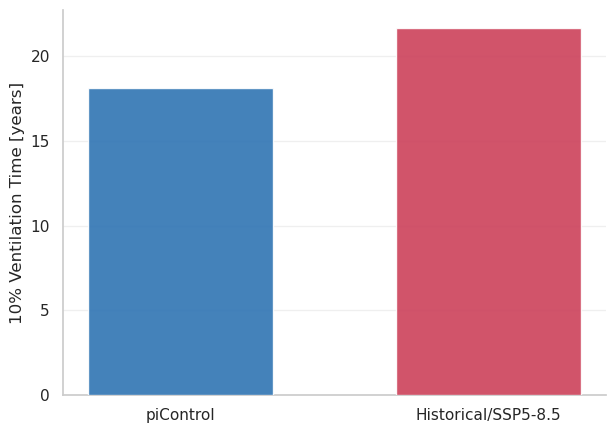

In [46]:
expt_labels = {"control": "piControl", "forced": "Historical/SSP5-8.5"}
expt_colors = {"control": "#2f74b3", "forced": "#cc415a"}

da = results["10_pct_ventilation_time"]  # DataArray with coord expt = ["control","forced"] (or similar)

keys = [k for k in ["control", "forced"] if k in da["expt"].values]
x = np.arange(len(keys))
y = np.array([da.sel(expt=k).item() for k in keys])
labels = [expt_labels[k] for k in keys]
colors = [expt_colors[k] for k in keys]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, y, color=colors, alpha = 0.9, zorder = 10, width = 0.6)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("10% Ventilation Time [years]")
ax.yaxis.grid(True, alpha=0.3, zorder = 0)
ax.xaxis.grid(False)
ax.spines[["top", "right"]].set_visible(False)
# ax.set_title("Age Spectrum for different CM4X scenarios", fontweight = "bold")

fig.savefig('plots/ross_adelie_10pct_ventilation.png', dpi = 150, bbox_inches = "tight")